In [ ]:
# Cell: Upload dataset
from google.colab import files
import pandas as pd

uploaded = files.upload()  # Select iris.csv from your computer
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)
print(df.head())
print(df['species'].value_counts())

Saving IRIS.csv to IRIS (1).csv
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [ ]:
print(df.columns)

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


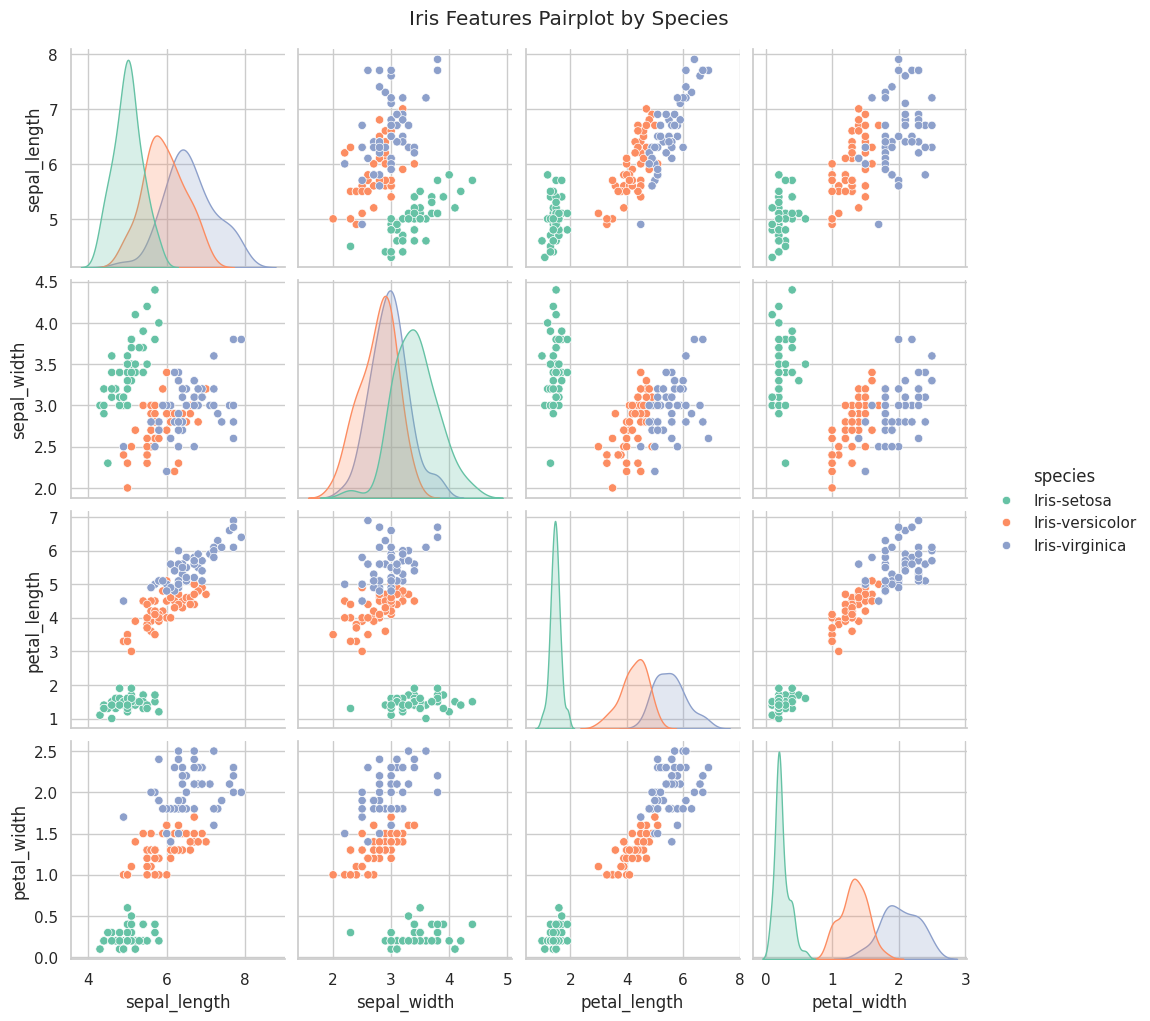

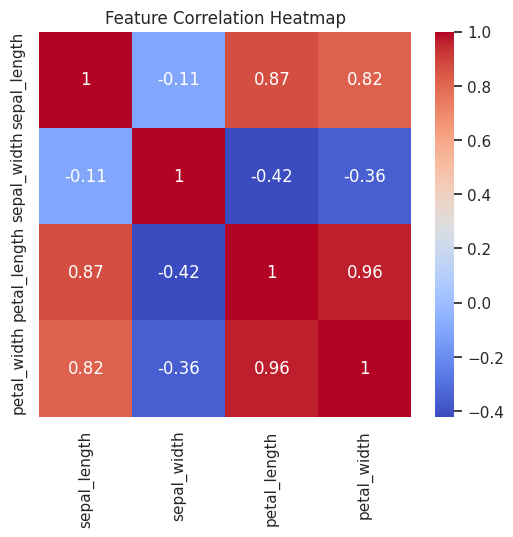

/tmp/ipykernel_570/2314975027.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feat, ax=ax, palette='Set2')
/tmp/ipykernel_570/2314975027.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feat, ax=ax, palette='Set2')
/tmp/ipykernel_570/2314975027.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feat, ax=ax, palette='Set2')
/tmp/ipykernel_570/2314975027.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.

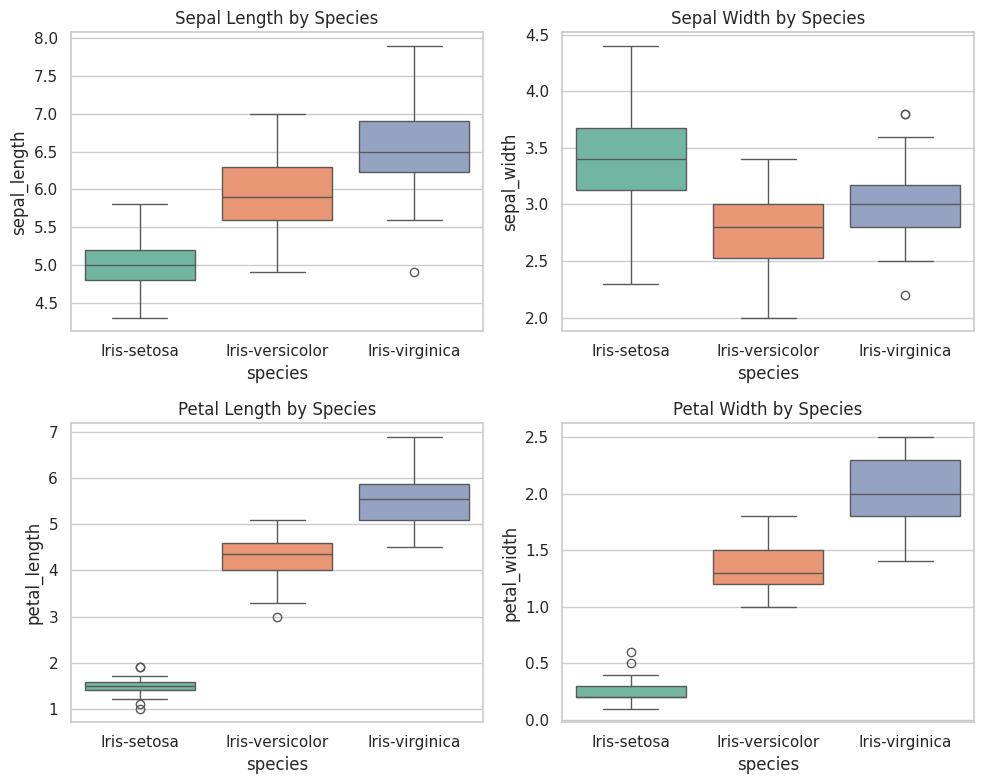

In [ ]:
# Cell: Imports and EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

# Use the df from previous cell (already loaded)

# Pairplot
sns.pairplot(df, hue='species', palette='Set2')
plt.suptitle('Iris Features Pairplot by Species', y=1.02)
plt.show()

# Correlation heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(6,5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

# Boxplots
fig, axes = plt.subplots(2, 2, figsize=(10,8))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(data=df, x='species', y=feat, ax=ax, palette='Set2')
    ax.set_title(f'{feat.replace("_", " ").title()} by Species')
plt.tight_layout()
plt.show()

In [ ]:
# Cell: Prepare data (use arrays from the start)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Convert to NumPy arrays immediately
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
y = df['species'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fits on array
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Cell: Train and evaluate models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

models = {
    'k-NN': KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    if name == 'k-NN':
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train, X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    results[name] = {
        'model': model,
        'accuracy': acc,
        'confusion_matrix': cm,
        'classification_report': report,
        'predictions': y_pred
    }

    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("Classification Report:")
    print(report)


=== k-NN ===
Accuracy: 0.9333
Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30


=== Logistic Regression ===
Accuracy: 0.9667
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg      

In [ ]:
# Cell: Download model files
from google.colab import files

files.download('models/best_iris_model.pkl')
files.download('models/scaler.pkl')

FileNotFoundError: Cannot find file: models/best_iris_model.pkl

In [ ]:
# Cell: Save model and scaler (both trained on arrays)
import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(best_model, 'models/best_iris_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("Model and scaler saved to models/")

Model and scaler saved to models/


In [ ]:
# Cell: Download model files
from google.colab import files

files.download('models/best_iris_model.pkl')
files.download('models/scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Cell: Inference example
import joblib
import numpy as np

model = joblib.load('models/best_iris_model.pkl')
scaler = joblib.load('models/scaler.pkl')

def predict_iris(sepal_length, sepal_width, petal_length, petal_width):
    X = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    X_scaled = scaler.transform(X)
    pred = model.predict(X_scaled)[0]
    return pred

# Example
sepal_length = 5.1
sepal_width = 3.5
petal_length = 1.4
petal_width = 0.2

species = predict_iris(sepal_length, sepal_width, petal_length, petal_width)
print(f"Predicted species: {species}")

Predicted species: Iris-setosa


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


# Cell: Accuracy comparison plot
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

acc_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results]
}).sort_values('Accuracy', ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(data=acc_df, x='Accuracy', y='Model', palette='Set2')
plt.title('Model Accuracy Comparison')
plt.xlim(0, 1.05)
for i, row in acc_df.iterrows():
    plt.text(row['Accuracy']+0.01, i, f"{row['Accuracy']:.3f}", va='center')
plt.tight_layout()
plt.show()

best_model_name = acc_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
print(f"Best model: {best_model_name} with accuracy {results[best_model_name]['accuracy']:.4f}")

In [ ]:
# Cell: Inference example (fixed warnings)
import joblib
import numpy as np
import pandas as pd

model = joblib.load('models/best_iris_model.pkl')
scaler = joblib.load('models/scaler.pkl')

# Use the same feature names as training
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

def predict_iris(sepal_length, sepal_width, petal_length, petal_width):
    # Create DataFrame with correct feature names
    X = pd.DataFrame([[sepal_length, sepal_width, petal_length, petal_width]],
                     columns=feature_names)
    X_scaled = scaler.transform(X)  # scaler expects DataFrame or array; this is fine
    pred = model.predict(X_scaled)[0]
    return pred

# Example
sepal_length = 5.1
sepal_width = 3.5
petal_length = 1.4
petal_width = 0.2

species = predict_iris(sepal_length, sepal_width, petal_length, petal_width)
print(f"Predicted species: {species}")

Predicted species: Iris-setosa


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Cell: Retrain best model using arrays (removes feature-name warnings)
import joblib
import numpy as np

best_model_name = acc_df.iloc[0]['Model']
print(f"Best model: {best_model_name}")

# Use scaled data if k-NN, else raw
if best_model_name == 'k-NN':
    X_tr = X_train_scaled
    X_te = X_test_scaled
else:
    X_tr = X_train.values  # convert DataFrame to array
    X_te = X_test.values

y_tr = y_train.values
y_te = y_test.values

# Retrain same model type on arrays
if best_model_name == 'k-NN':
    from sklearn.neighbors import KNeighborsClassifier
    best_model = KNeighborsClassifier(n_neighbors=5)
elif best_model_name == 'Logistic Regression':
    from sklearn.linear_model import LogisticRegression
    best_model = LogisticRegression(max_iter=200)
elif best_model_name == 'Decision Tree':
    from sklearn.tree import DecisionTreeClassifier
    best_model = DecisionTreeClassifier(random_state=42)

best_model.fit(X_tr, y_tr)

# Quick check
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_te, best_model.predict(X_te))
print(f"Retrained model accuracy: {acc:.4f}")

# Save this version
joblib.dump(best_model, 'models/best_iris_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

Best model: Logistic Regression
Retrained model accuracy: 0.9667


['models/scaler.pkl']

In [ ]:
# Cell: Inference example (no warnings)
import joblib
import numpy as np

model = joblib.load('models/best_iris_model.pkl')
scaler = joblib.load('models/scaler.pkl')

def predict_iris(sepal_length, sepal_width, petal_length, petal_width):
    X = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    X_scaled = scaler.transform(X)
    pred = model.predict(X_scaled)[0]
    return pred

# Example
sepal_length = 5.1
sepal_width = 3.5
petal_length = 1.4
petal_width = 0.2

species = predict_iris(sepal_length, sepal_width, petal_length, petal_width)
print(f"Predicted species: {species}")

Predicted species: Iris-setosa


In [ ]:
from google.colab import files
files.download('models/best_iris_model.pkl')
files.download('models/scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>